<a href="https://colab.research.google.com/github/Erjg1012/predicciones/blob/main/asignaci%C3%B3n_de_cr%C3%A9ditos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("bank-full.csv", sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df['y'].value_counts()

,count
y,
no,39922
yes,5289


In [ ]:

# 1. Contar 'unknown'
print("Conteo de 'unknown':")
print((df == 'unknown').sum())


Conteo de 'unknown':
age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays            0
previous         0
poutcome     36959
y                0
dtype: int64


In [ ]:
df = df.replace('unknown', pd.NA).dropna()
print("Conteo de 'unknown':")
print((df == 'unknown').sum())


Conteo de 'unknown':
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [ ]:
df['y'].value_counts()

,count
y,
no,6056
yes,1786


In [ ]:
print("\n\nDistribución de la variable objetivo (%): \n")
y_counts = df['y'].value_counts()
print(y_counts)



Distribución de la variable objetivo (%): 

y
no     6056
yes    1786
Name: count, dtype: int64


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7842 entries, 24060 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        7842 non-null   int64 
 1   job        7842 non-null   object
 2   marital    7842 non-null   object
 3   education  7842 non-null   object
 4   default    7842 non-null   object
 5   balance    7842 non-null   int64 
 6   housing    7842 non-null   object
 7   loan       7842 non-null   object
 8   contact    7842 non-null   object
 9   day        7842 non-null   int64 
 10  month      7842 non-null   object
 11  duration   7842 non-null   int64 
 12  campaign   7842 non-null   int64 
 13  pdays      7842 non-null   int64 
 14  previous   7842 non-null   int64 
 15  poutcome   7842 non-null   object
 16  y          7842 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.1+ MB


,age,balance,day,duration,campaign,pdays,previous
count,7842.000000,7842.000000,7842.000000,7842.000000,7842.000000,7842.000000,7842.000000
mean,40.783856,1552.343280,14.260010,261.290615,2.064269,223.252869,3.184264
std,11.282964,3084.580003,7.885328,236.203272,1.566109,111.830127,4.614190
min,18.000000,-1884.000000,1.000000,5.000000,1.000000,1.000000,1.000000
25%,32.000000,162.000000,7.000000,113.000000,1.000000,133.000000,1.000000
50%,38.000000,595.000000,14.000000,194.000000,2.000000,195.000000,2.000000
75%,47.000000,1733.750000,20.000000,324.000000,2.000000,326.000000,4.000000
max,89.000000,81204.000000,31.000000,2219.000000,16.000000,871.000000,275.000000


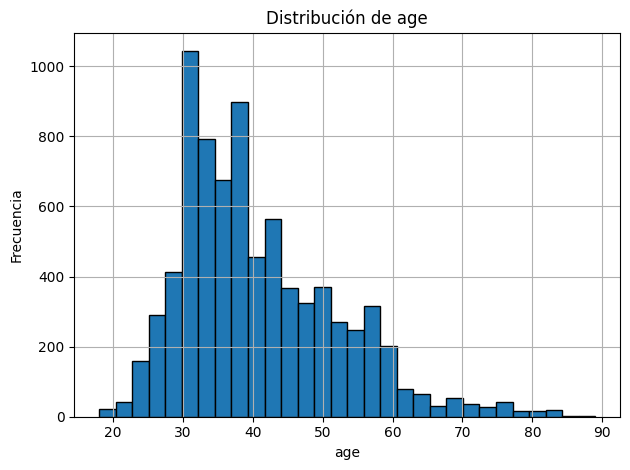

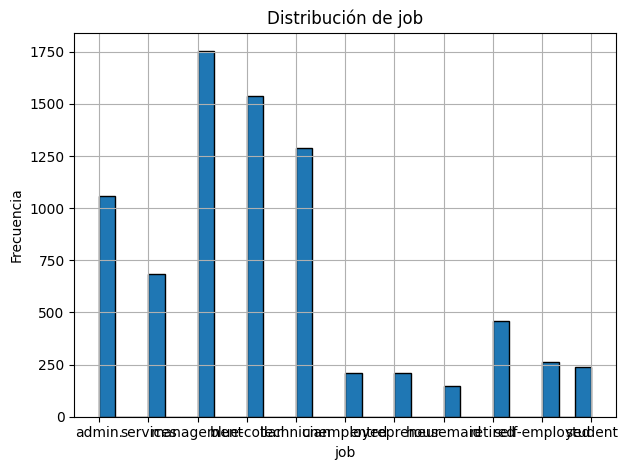

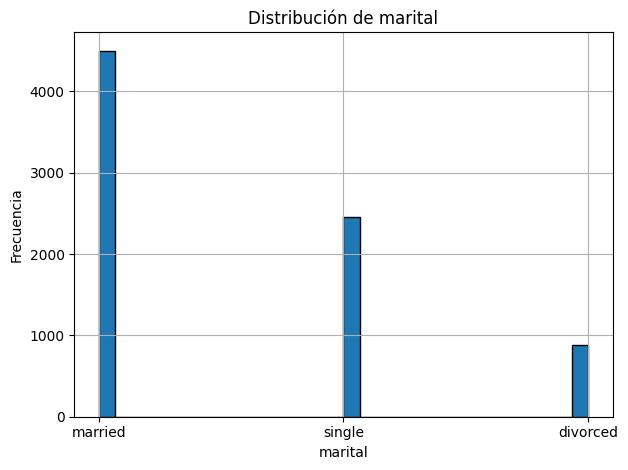

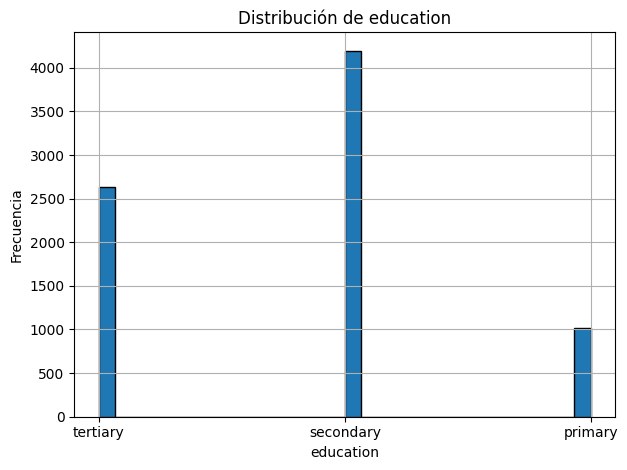

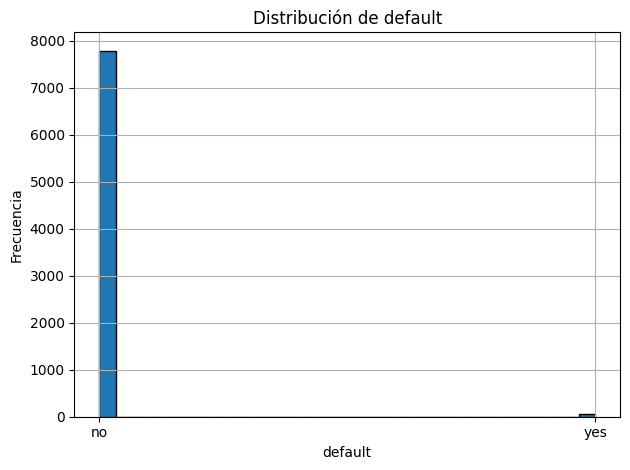

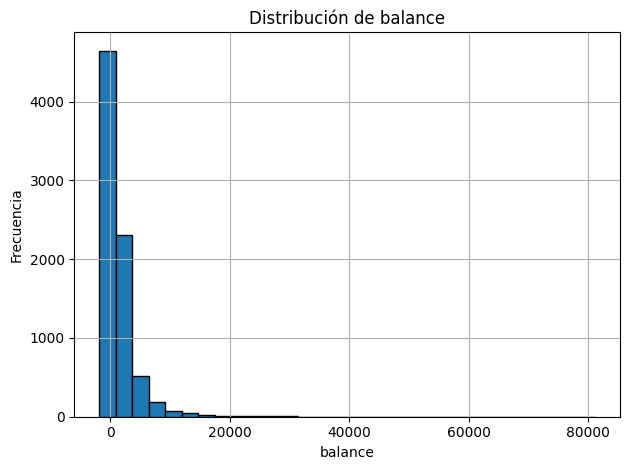

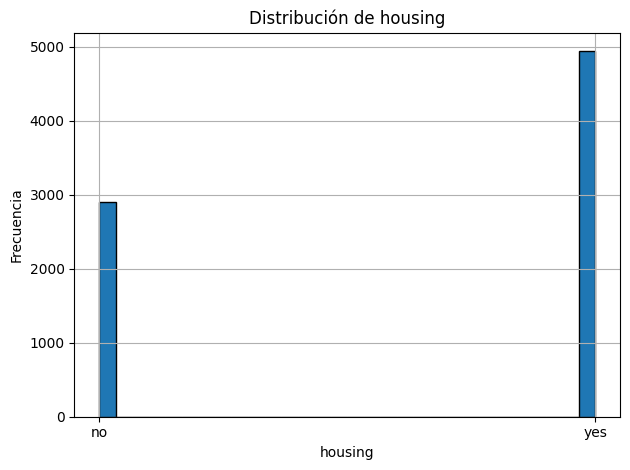

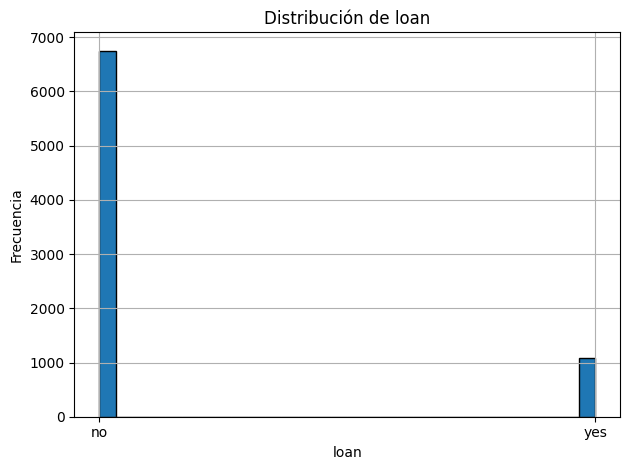

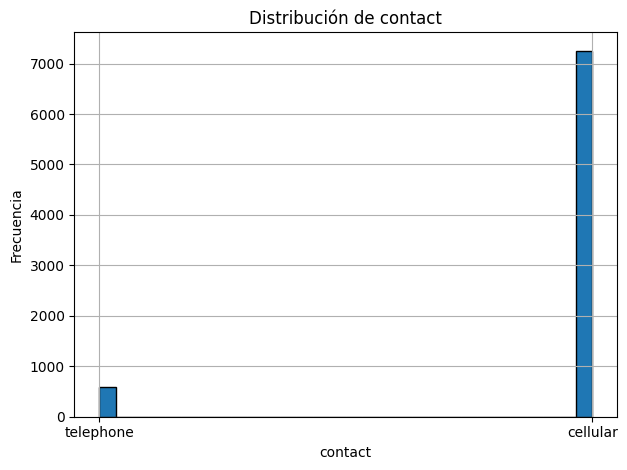

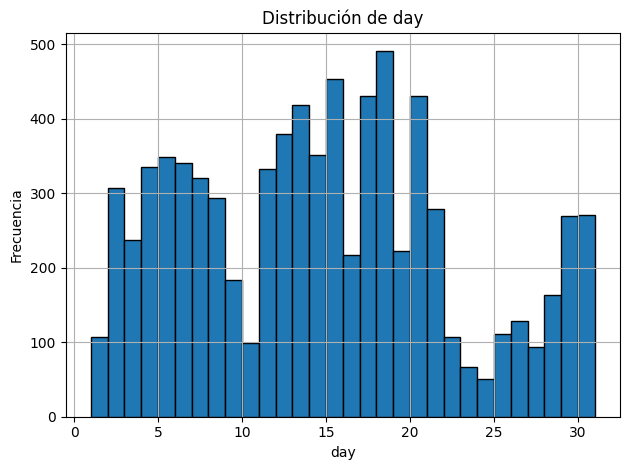

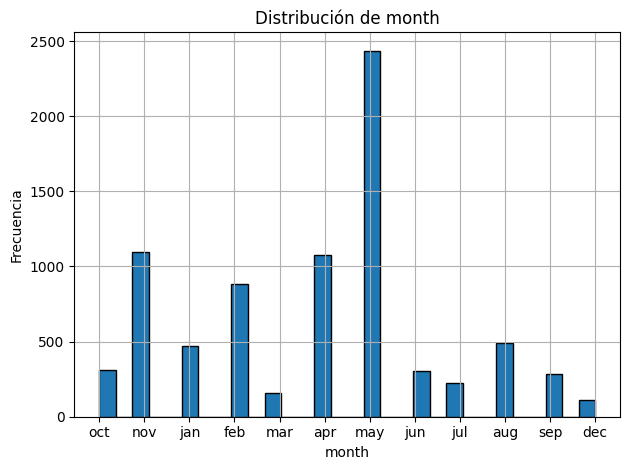

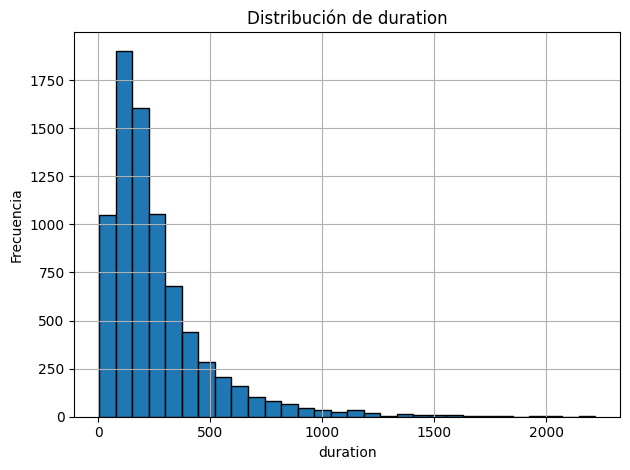

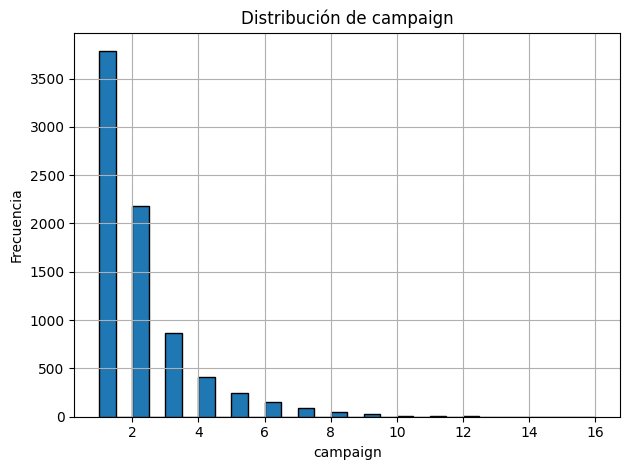

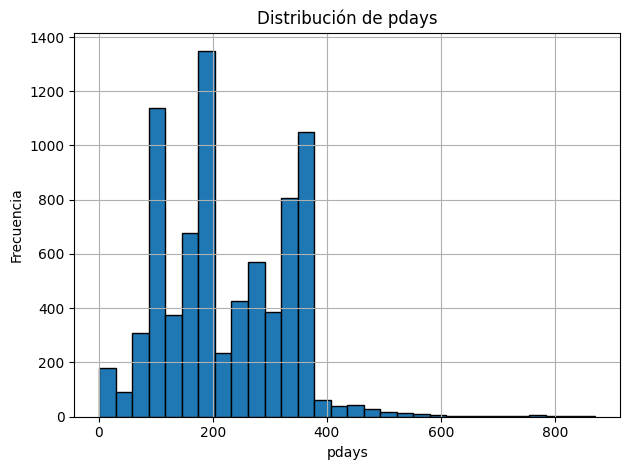

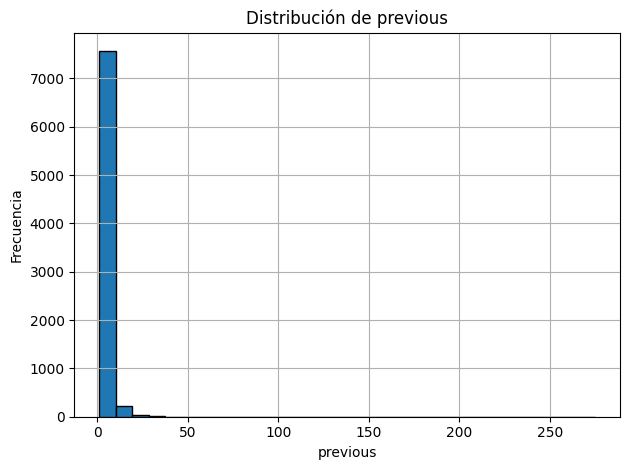

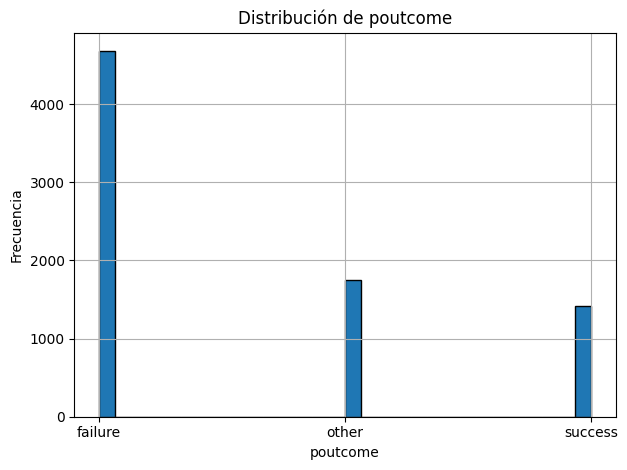

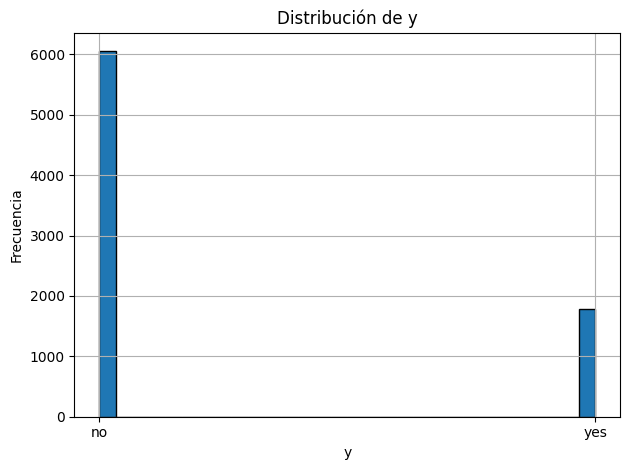

In [ ]:
# Seleccionar las variables de interés
variables = ['age','job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact','day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

# Crear histogramas para cada variable
for var in variables:
    plt.figure()
    plt.hist(df[var], bins=30, edgecolor='black')
    plt.title(f'Distribución de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

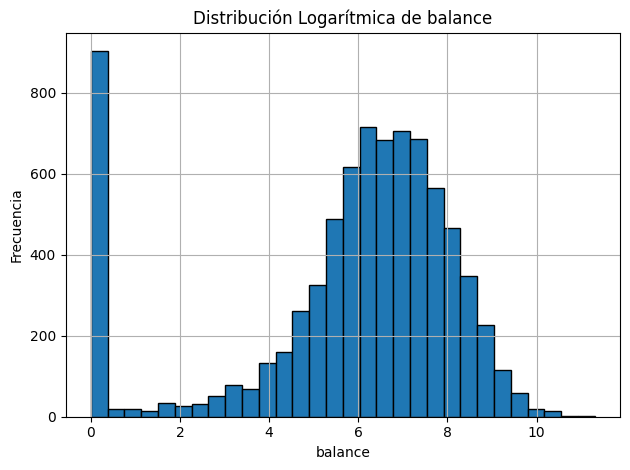

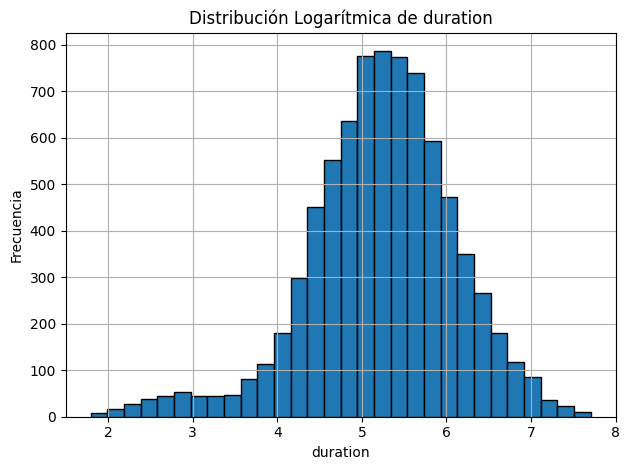

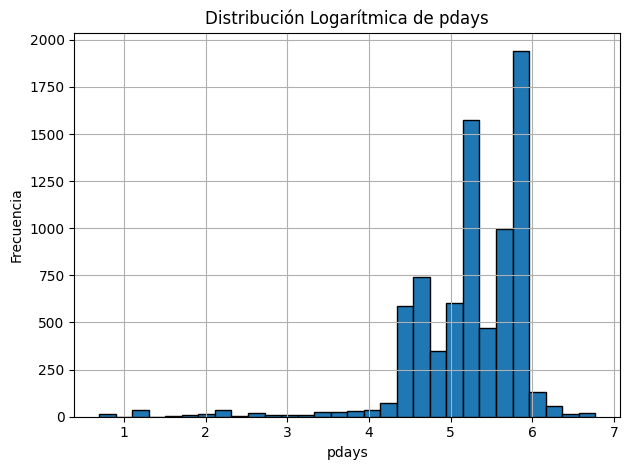

In [ ]:
df['balance'] = np.log1p(df['balance'].clip(lower=0))
df['duration'] = np.log1p(df['duration'].clip(lower=0))
df['pdays'] = np.log1p(df['pdays'].where(df['pdays'] >= 0))

# Graficar las nuevas distribuciones
for var in ['balance', 'duration', 'pdays']:
    plt.figure()
    plt.hist(df[var].dropna(), bins=30, edgecolor='black')
    plt.title(f'Distribución Logarítmica de {var}')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

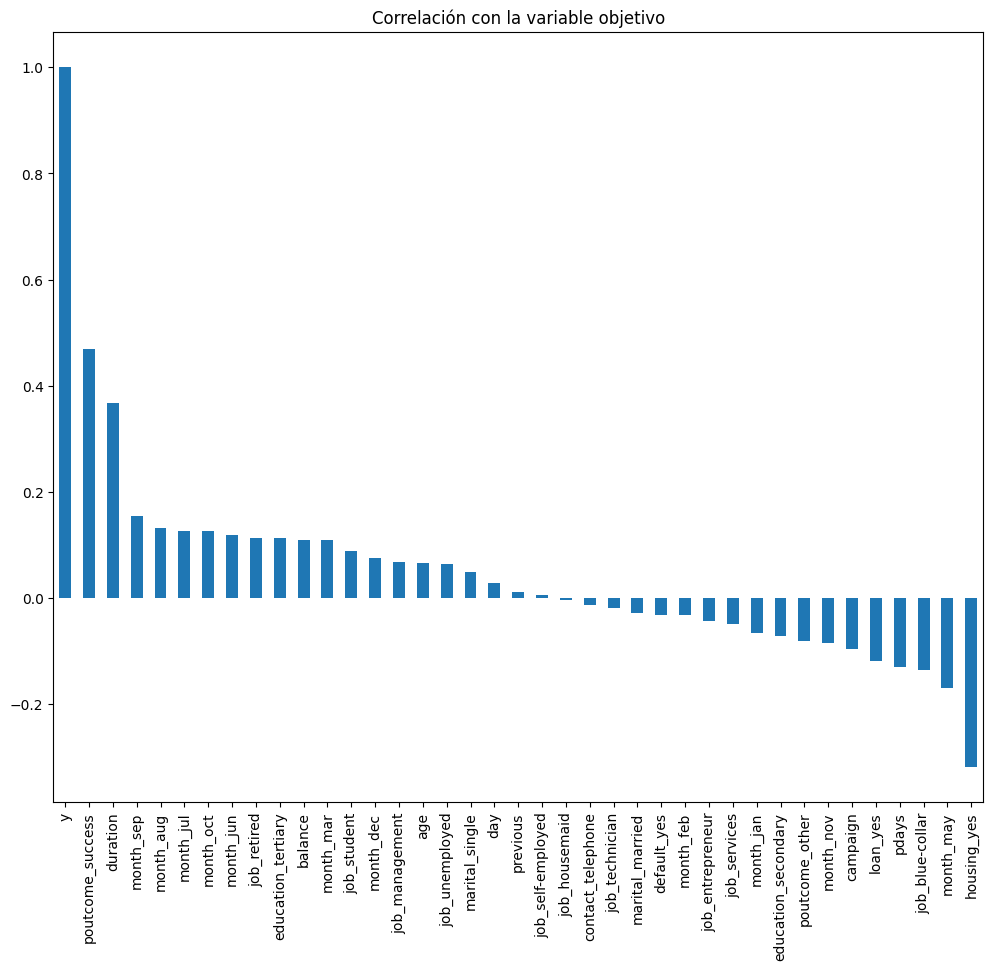

Top características por ANOVA:
    Feature   ANOVA_Score   ANOVA_pvalue
7         y  2.703975e+17   0.000000e+00
3  duration  1.221027e+03  9.399181e-249
5     pdays  1.321140e+02   2.470039e-30
1   balance  9.428290e+01   3.644777e-22
4  campaign  7.214206e+01   2.372380e-17
0       age  3.541009e+01   2.785812e-09
2       day  6.840249e+00   8.929715e-03
6  previous  1.202409e+00   2.728743e-01

Top características por Chi-cuadrado:
             Feature   Chi2_Score    Chi2_pvalue
30  poutcome_success  1411.137484  7.984301e-309
15       housing_yes   294.021263   6.612718e-66
28         month_sep   182.621916   1.297096e-41
25         month_may   155.115539   1.321129e-35
18         month_aug   128.900793   7.129425e-30
22         month_jul   122.963333   1.420499e-28
27         month_oct   119.395028   8.581868e-28
0    job_blue-collar   115.957283   4.856453e-27
23         month_jun   106.523932   5.660478e-25
4        job_retired    95.462969   1.506837e-22

Top características p

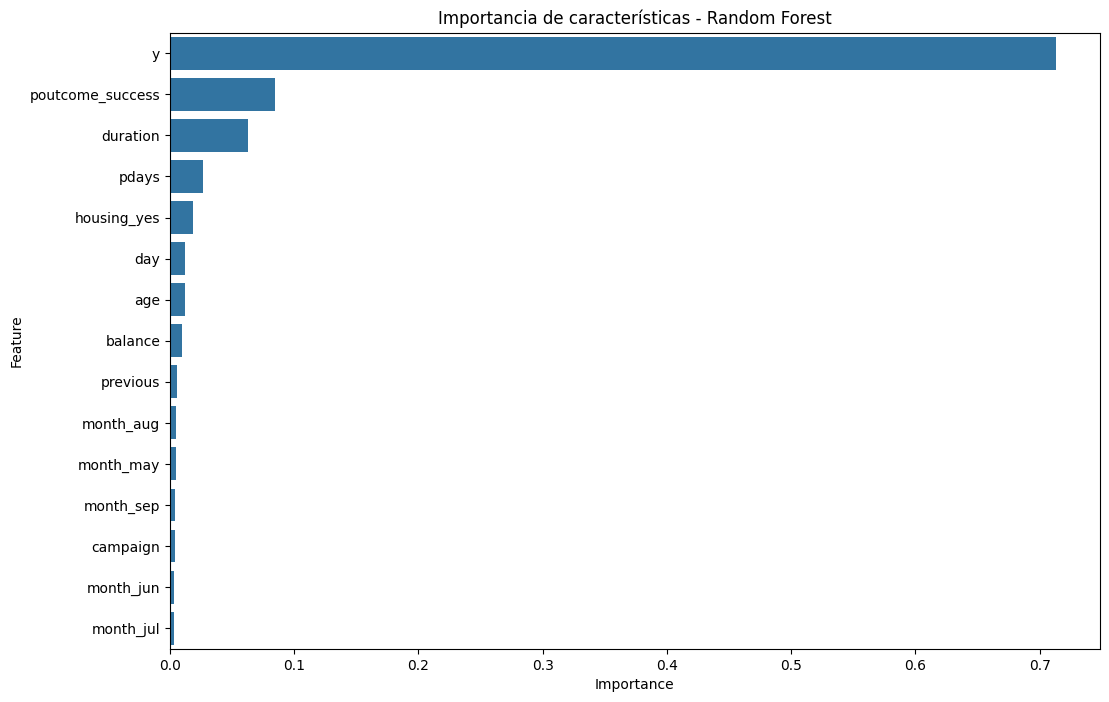


Ranking consolidado de características:
y                    2
poutcome_success     3
duration             5
pdays                7
housing_yes          7
balance             12
day                 13
age                 13
month_aug           15
month_may           15
month_sep           15
previous            17
campaign            18
month_jul           21
month_jun           23
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preprocesamiento básico
# Codificar variables categóricas (si existen)
df_encoded = pd.get_dummies(df, drop_first=True)

# Codificar la variable objetivo si es categórica
le = LabelEncoder()
y = pd.Series(le.fit_transform(df['y']), index=df_encoded.index)

# 2. Análisis de correlación (para variables numéricas)
plt.figure(figsize=(12, 10))
corr_matrix = df_encoded.corrwith(pd.Series(y)).sort_values(ascending=False)
corr_matrix.plot(kind='bar', title='Correlación con la variable objetivo')
plt.show()

# 3. Pruebas estadísticas ANOVA (para variables numéricas)
X_num = df_encoded.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# Selección de características con ANOVA
selector_anova = SelectKBest(score_func=f_classif, k='all')
selector_anova.fit(X_scaled, y)

# Resultados ANOVA
anova_scores = pd.DataFrame({
    'Feature': X_num.columns,
    'ANOVA_Score': selector_anova.scores_,
    'ANOVA_pvalue': selector_anova.pvalues_
}).sort_values('ANOVA_Score', ascending=False)

print("Top características por ANOVA:")
print(anova_scores.head(10))

# 4. Prueba chi-cuadrado (para variables categóricas)
# Primero asegurarse de que todos los valores son no negativos
X_cat = df_encoded.select_dtypes(include=['uint8', 'bool']).clip(lower=0)

if not X_cat.empty:
    selector_chi2 = SelectKBest(score_func=chi2, k='all')
    selector_chi2.fit(X_cat, y)

    chi2_scores = pd.DataFrame({
        'Feature': X_cat.columns,
        'Chi2_Score': selector_chi2.scores_,
        'Chi2_pvalue': selector_chi2.pvalues_
    }).sort_values('Chi2_Score', ascending=False)

    print("\nTop características por Chi-cuadrado:")
    print(chi2_scores.head(10))

# 5. Importancia de características con Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(df_encoded, y)

feature_importances = pd.DataFrame({
    'Feature': df_encoded.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop características por Random Forest:")
print(feature_importances.head(10))

# Visualización de importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(15))
plt.title('Importancia de características - Random Forest')
plt.show()

# 6. Combinación de resultados (ejemplo)
# Crear un ranking consolidado
ranking = {}
for i, feature in enumerate(feature_importances['Feature']):
    ranking[feature] = i + 1

for i, feature in enumerate(anova_scores['Feature']):
    ranking[feature] = ranking.get(feature, 0) + (i + 1)

if not X_cat.empty:
    for i, feature in enumerate(chi2_scores['Feature']):
        ranking[feature] = ranking.get(feature, 0) + (i + 1)

# Ordenar por mejor ranking promedio
final_ranking = pd.Series(ranking).sort_values()
print("\nRanking consolidado de características:")
print(final_ranking.head(15))

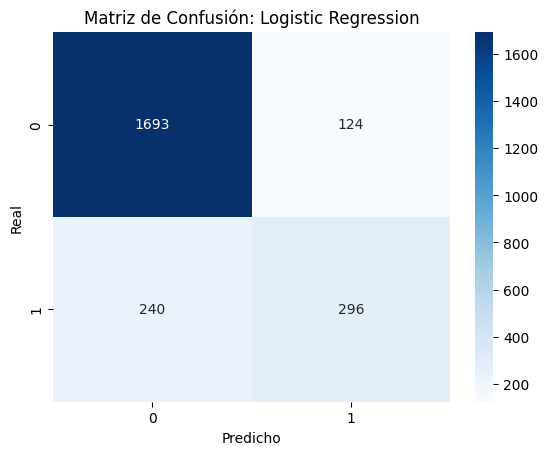

Logistic Regression - Cross Validation F1: 0.6949 ± 0.1343


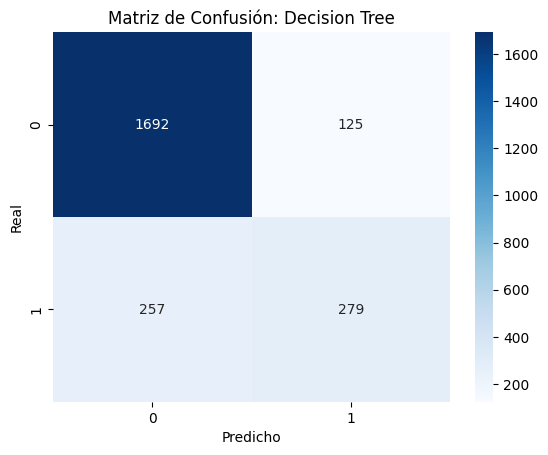

Decision Tree - Cross Validation F1: 0.7546 ± 0.0641


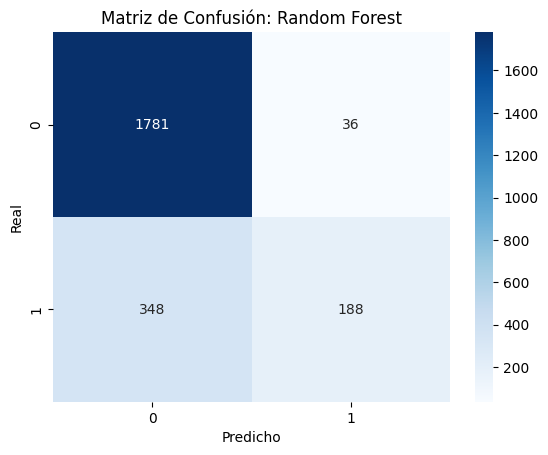

Random Forest - Cross Validation F1: 0.7274 ± 0.0643


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


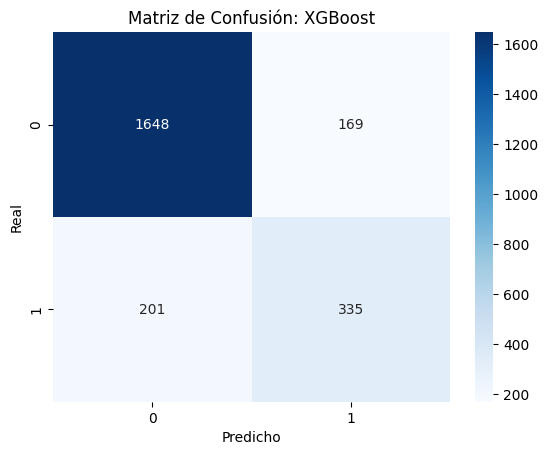

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

XGBoost - Cross Validation F1: 0.5940 ± 0.1263

Comparación de Modelos:
                     accuracy  precision    recall  f1-score       auc
Logistic Regression  0.845304   0.836870  0.845304  0.838311  0.899836
Decision Tree        0.837654   0.827694  0.837654  0.829100  0.872077
Random Forest        0.836804   0.837168  0.836804  0.809758  0.890622
XGBoost              0.842754   0.839672  0.842754  0.841021  0.907013


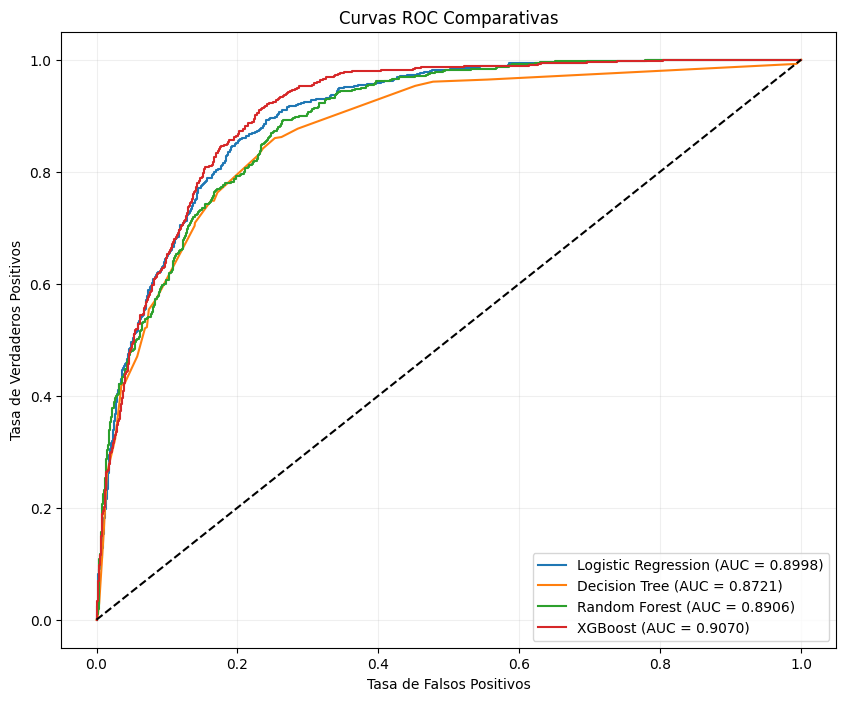

<Figure size 1200x600 with 0 Axes>

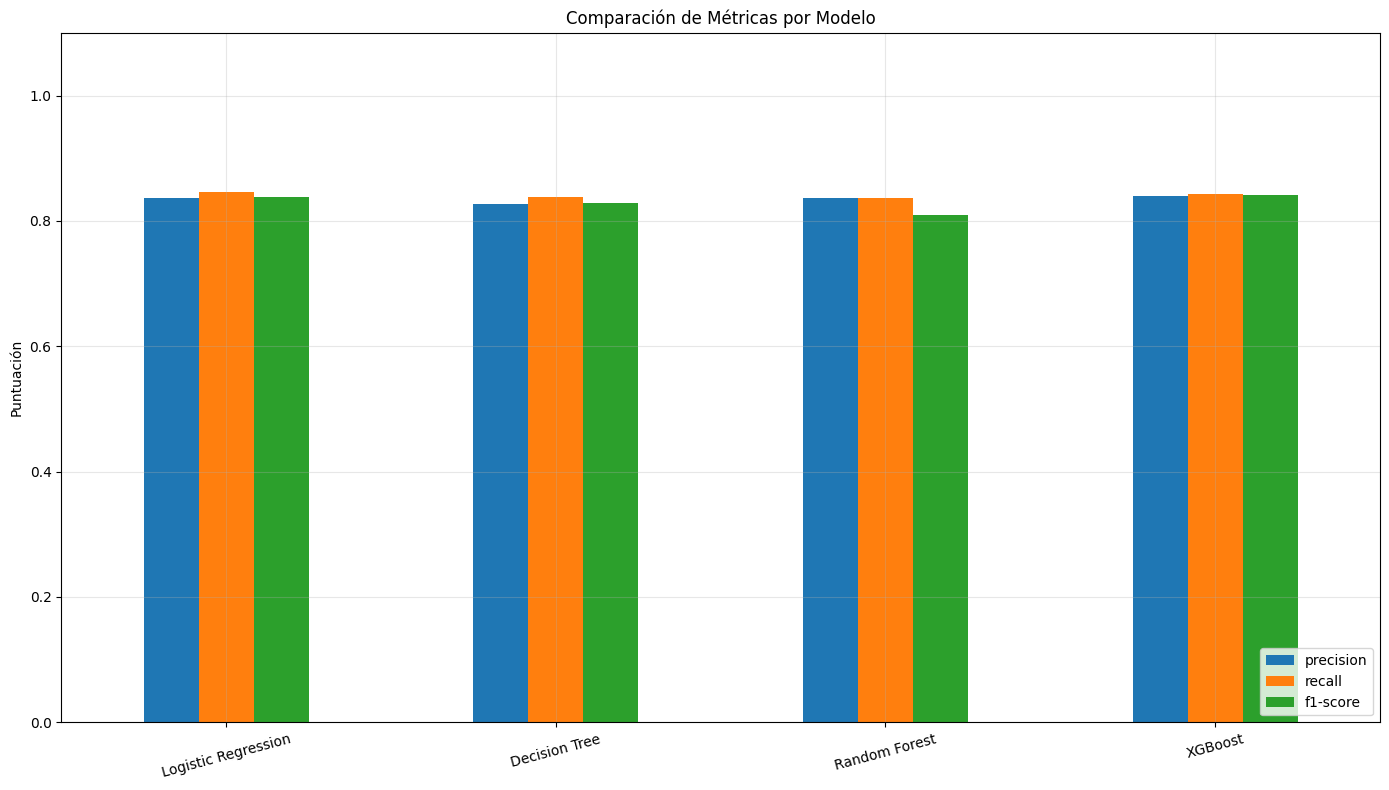

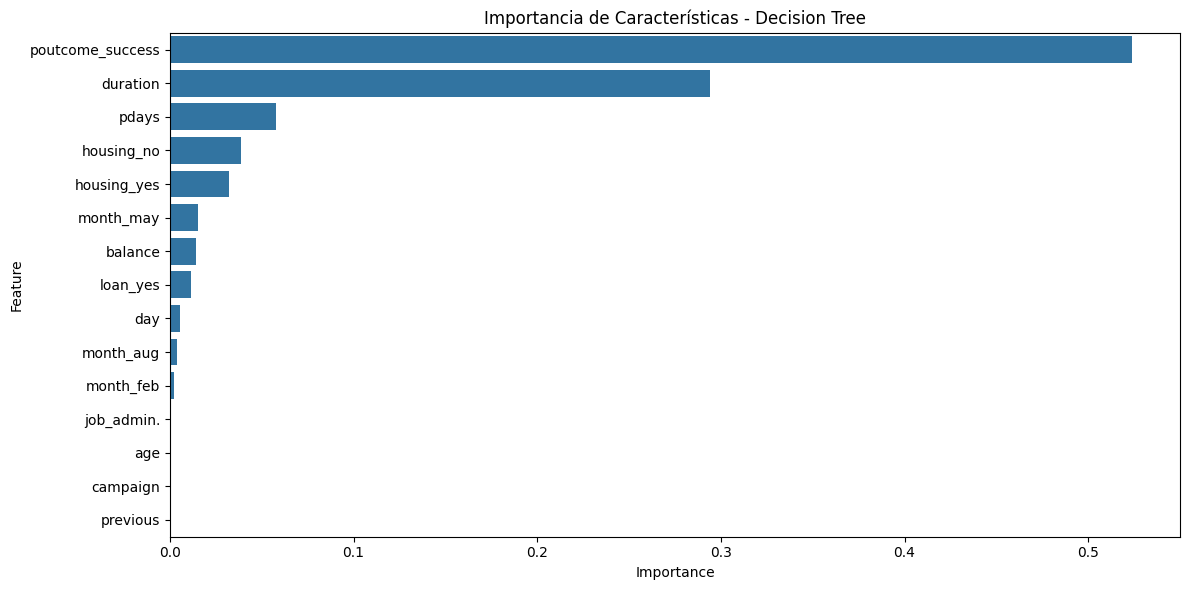

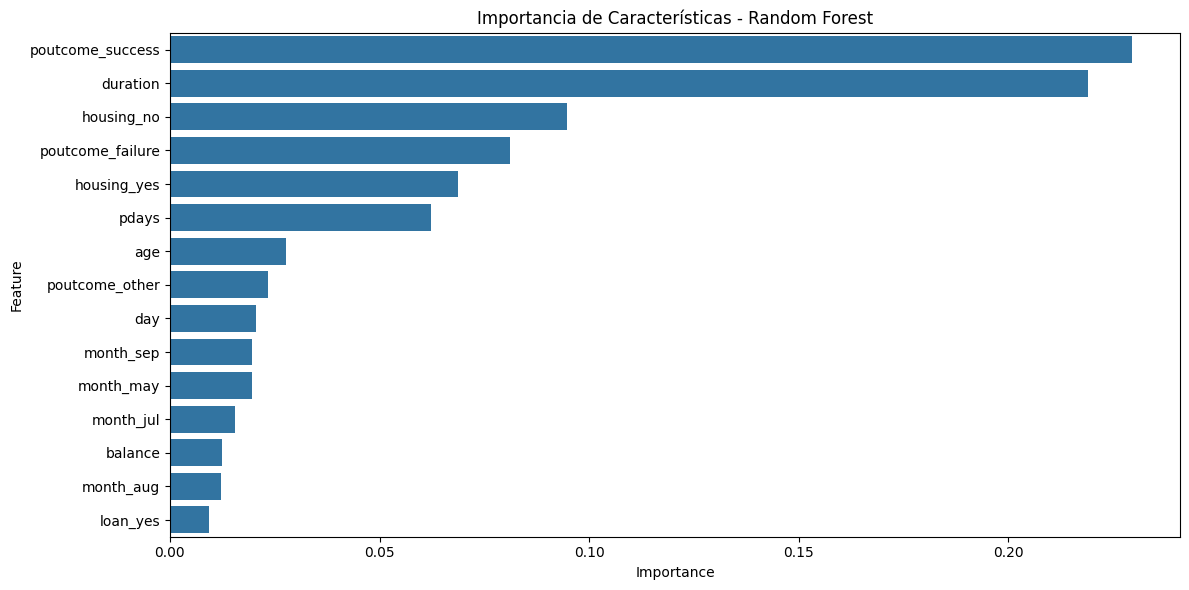

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:13:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


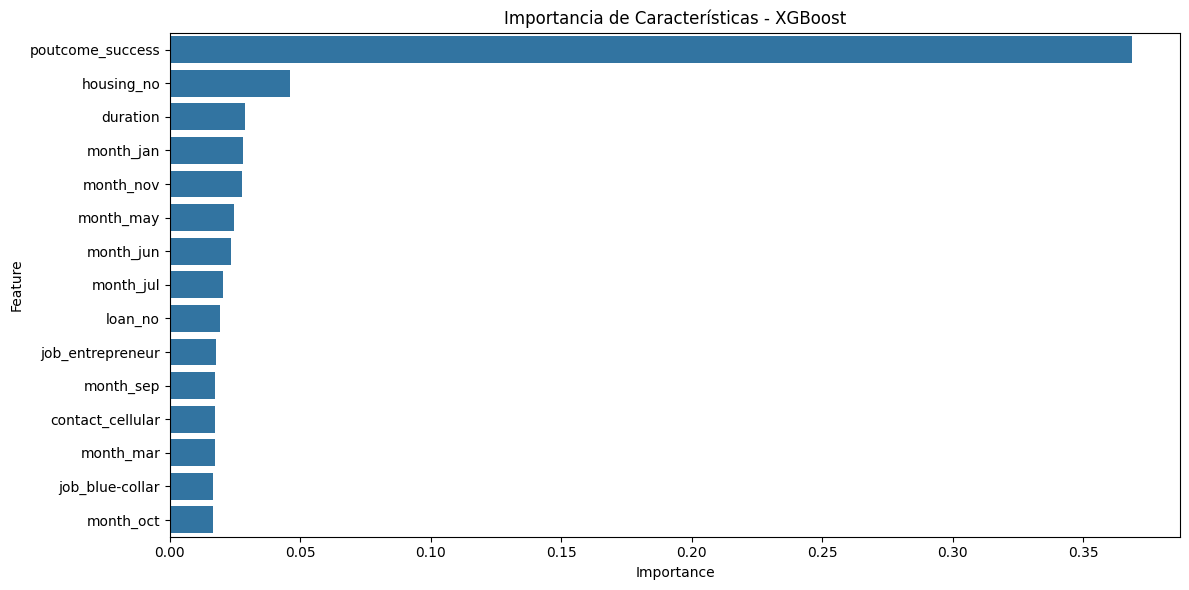

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Solución al error: Convertir la variable objetivo a valores numéricos
le = LabelEncoder()
df['y'] = le.fit_transform(df['y'])

# 1. Preparación de datos
X = df.drop('y', axis=1)
y = df['y']

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Identificar tipos de columnas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 2. Definición de modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 3. Entrenamiento y evaluación
results = {}
roc_data = {}

for name, model in models.items():
    # Crear pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Entrenar modelo
    pipeline.fit(X_train, y_train)

    # Predecir
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # Probabilidad de clase positiva

    # Métricas
    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    # Almacenar resultados
    results[name] = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1-score': report['weighted avg']['f1-score'],
        'auc': auc
    }

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

    # Matriz de confusión
    plt.figure()
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.show()

    # Validación cruzada
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1_weighted')
    print(f"{name} - Cross Validation F1: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# 4. Resultados comparativos
results_df = pd.DataFrame(results).T
print("\nComparación de Modelos:")
print(results_df)

# 5. Gráfico comparativo de ROC
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC Comparativas')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.show()

# 6. Gráfico de barras comparativas
plt.figure(figsize=(12, 6))
results_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 8))
plt.title('Comparación de Métricas por Modelo')
plt.ylabel('Puntuación')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 7. Feature Importance (para modelos basados en árboles)
for name in ["Decision Tree", "Random Forest", "XGBoost"]:
    # Obtener nombres de características después del preprocesamiento
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', models[name])
    ])
    pipeline.fit(X_train, y_train)

    # Obtener nombres de características
    feature_names = numeric_cols.tolist()
    if len(categorical_cols) > 0:
        ohe_features = pipeline.named_steps['preprocessor'].named_transformers_['cat']\
            .get_feature_names_out(categorical_cols)
        feature_names.extend(ohe_features)

    # Obtener importancias
    if name == "Decision Tree":
        importances = pipeline.named_steps['classifier'].feature_importances_
    elif name == "Random Forest":
        importances = pipeline.named_steps['classifier'].feature_importances_
    elif name == "XGBoost":
        importances = pipeline.named_steps['classifier'].feature_importances_

    # Crear DataFrame
    feature_importances = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    # Graficar
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances)
    plt.title(f'Importancia de Características - {name}')
    plt.tight_layout()
    plt.show()

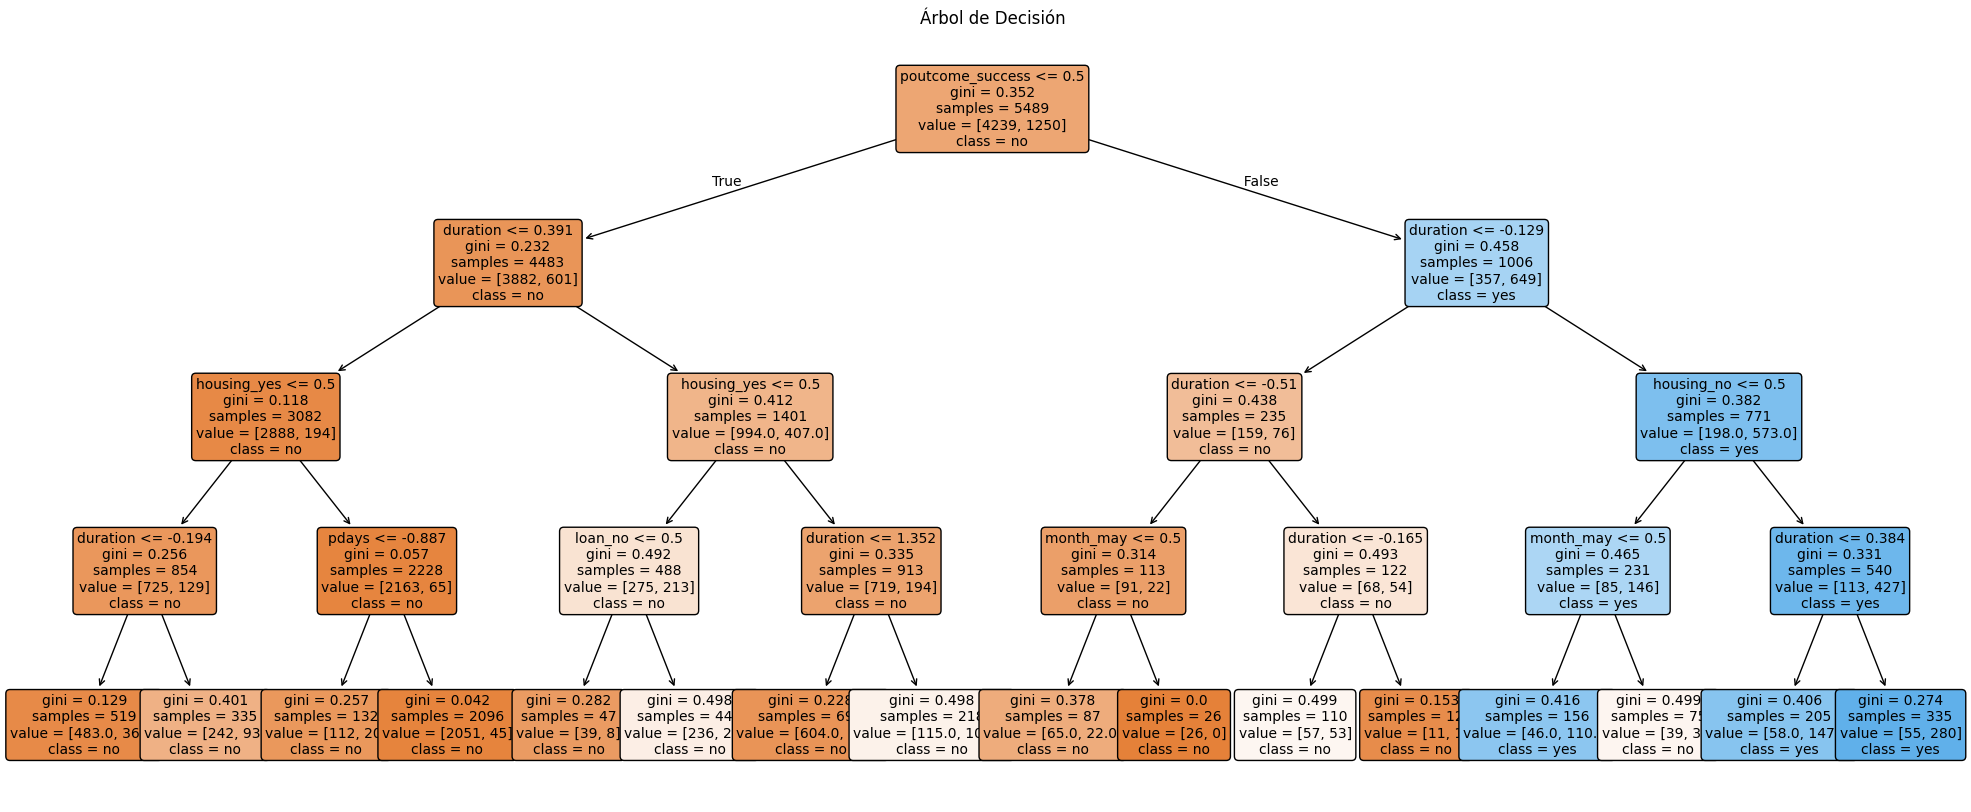

Reglas del Árbol de Decisión:

|--- poutcome_success <= 0.50
|   |--- duration <= 0.39
|   |   |--- housing_yes <= 0.50
|   |   |   |--- duration <= -0.19
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  -0.19
|   |   |   |   |--- class: 0
|   |   |--- housing_yes >  0.50
|   |   |   |--- pdays <= -0.89
|   |   |   |   |--- class: 0
|   |   |   |--- pdays >  -0.89
|   |   |   |   |--- class: 0
|   |--- duration >  0.39
|   |   |--- housing_yes <= 0.50
|   |   |   |--- loan_no <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- loan_no >  0.50
|   |   |   |   |--- class: 0
|   |   |--- housing_yes >  0.50
|   |   |   |--- duration <= 1.35
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  1.35
|   |   |   |   |--- class: 0
|--- poutcome_success >  0.50
|   |--- duration <= -0.13
|   |   |--- duration <= -0.51
|   |   |   |--- month_may <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- month_may >  0.50
|   |   |   |   |--- class: 0
|   |   |--- duration >  -0.5

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Entrenamiento
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', dt_model)
])
dt_pipeline.fit(X_train, y_train)

# Obtener nombres de características
feature_names = numeric_cols.tolist()
if len(categorical_cols) > 0:
    ohe_features = dt_pipeline.named_steps['preprocessor'].named_transformers_['cat']\
        .get_feature_names_out(categorical_cols)
    feature_names.extend(ohe_features)

class_names = ['no', 'yes']  # Ajusta esto si las clases originales eran otras

plt.figure(figsize=(25, 10))
plot_tree(dt_pipeline.named_steps['classifier'],
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión")
plt.show()

# Reglas del árbol
rules = export_text(dt_pipeline.named_steps['classifier'], feature_names=feature_names)
print("Reglas del Árbol de Decisión:\n")
print(rules)


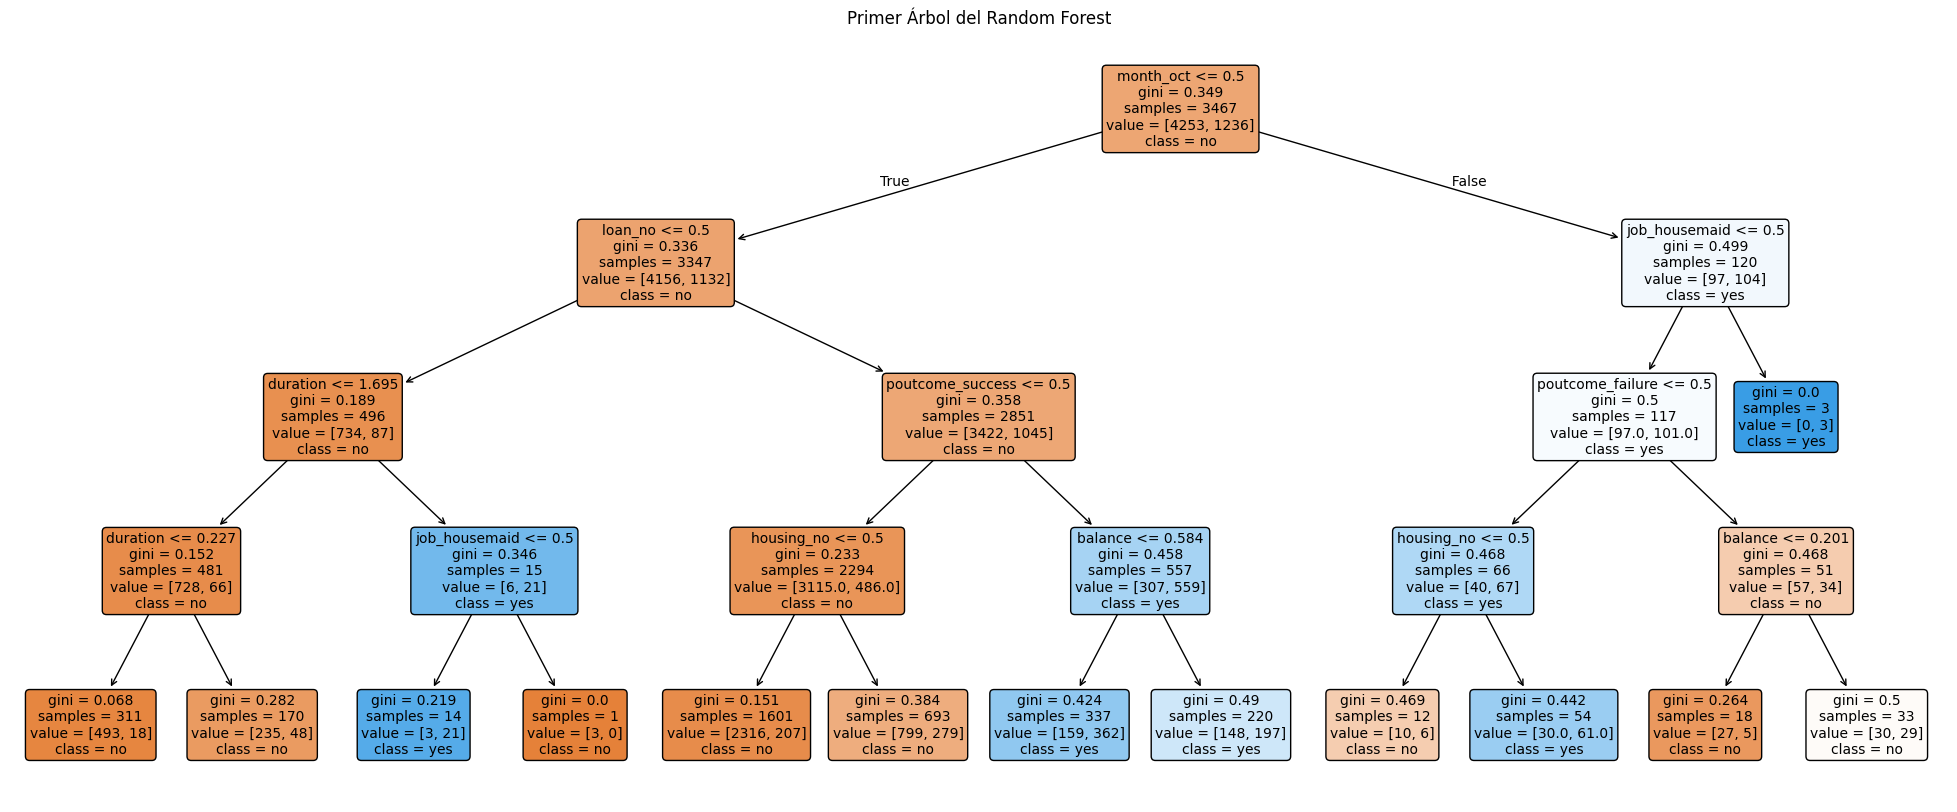

Reglas del Árbol de Decisión:

|--- poutcome_success <= 0.50
|   |--- duration <= 0.39
|   |   |--- housing_yes <= 0.50
|   |   |   |--- duration <= -0.19
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  -0.19
|   |   |   |   |--- class: 0
|   |   |--- housing_yes >  0.50
|   |   |   |--- pdays <= -0.89
|   |   |   |   |--- class: 0
|   |   |   |--- pdays >  -0.89
|   |   |   |   |--- class: 0
|   |--- duration >  0.39
|   |   |--- housing_yes <= 0.50
|   |   |   |--- loan_no <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- loan_no >  0.50
|   |   |   |   |--- class: 0
|   |   |--- housing_yes >  0.50
|   |   |   |--- duration <= 1.35
|   |   |   |   |--- class: 0
|   |   |   |--- duration >  1.35
|   |   |   |   |--- class: 0
|--- poutcome_success >  0.50
|   |--- duration <= -0.13
|   |   |--- duration <= -0.51
|   |   |   |--- month_may <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- month_may >  0.50
|   |   |   |   |--- class: 0
|   |   |--- duration >  -0.5

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Entrenamiento
rf_model = RandomForestClassifier(n_estimators=10, random_state=42, max_depth=4)
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])
rf_pipeline.fit(X_train, y_train)

class_names = ['no', 'yes']  # Ajusta esto si las clases originales eran otras

# Primer árbol del bosque
rf_tree = rf_pipeline.named_steps['classifier'].estimators_[0]

plt.figure(figsize=(25, 10))
plot_tree(rf_tree,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Primer Árbol del Random Forest")
plt.show()

# Reglas del árbol
rules = export_text(dt_pipeline.named_steps['classifier'], feature_names=feature_names)
print("Reglas del Árbol de Decisión:\n")
print(rules)

In [ ]:
from xgboost import XGBClassifier

# Entrenamiento
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])
xgb_pipeline.fit(X_train, y_train)

# Obtener resumen del primer árbol
booster = xgb_pipeline.named_steps['classifier'].get_booster()
xgb_df = booster.trees_to_dataframe()
print("Resumen del primer árbol de XGBoost:")
display(xgb_df[xgb_df['Tree'] == 0].head(10))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:10:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Resumen del primer árbol de XGBoost:


,Tree,Node,ID,Feature,Split,Yes,No,Missing,Gain,Cover,Category
0,0,0,0-0,f46,1.000000,0-1,0-2,0-2,1134.404300,1034.083130,NaN
1,0,1,0-1,f3,0.392943,0-3,0-4,0-4,264.093750,844.560852,NaN
2,0,2,0-2,f3,-0.125259,0-5,0-6,0-6,165.906433,189.522247,NaN
3,0,3,0-3,f26,1.000000,0-7,0-8,0-8,48.004822,580.623840,NaN
4,0,4,0-4,f26,1.000000,0-9,0-10,0-10,83.740433,263.937042,NaN
5,0,5,0-5,f3,-0.504998,0-11,0-12,0-12,18.211762,44.272095,NaN
6,0,6,0-6,f26,1.000000,0-13,0-14,0-14,16.301392,145.250153,NaN
7,0,7,0-7,f5,-0.879763,0-15,0-16,0-16,10.777344,419.737152,NaN
8,0,8,0-8,f3,-0.190369,0-17,0-18,0-18,46.202942,160.886673,NaN
9,0,9,0-9,f3,1.401375,0-19,0-20,0-20,99.995514,172.001801,NaN


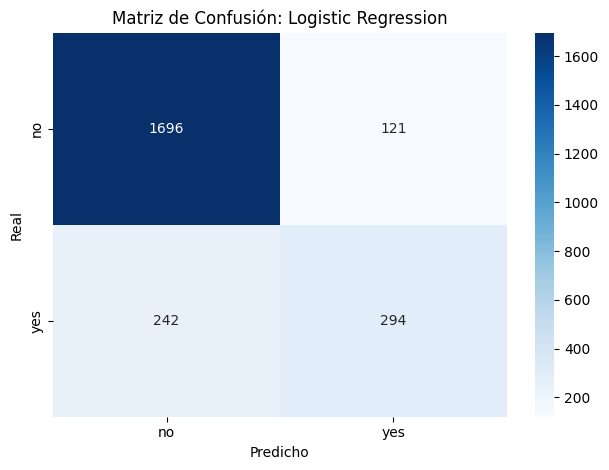

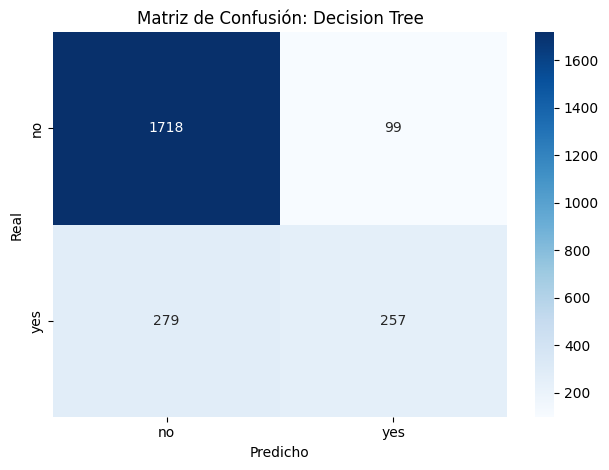

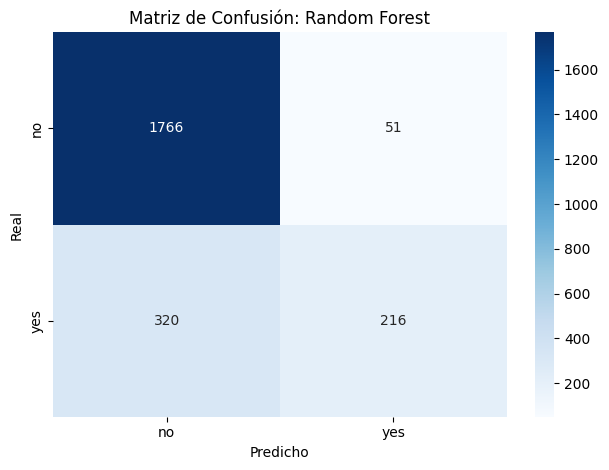

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:29:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


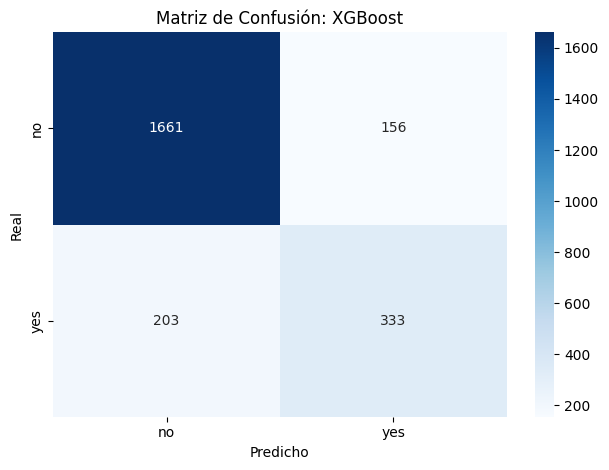

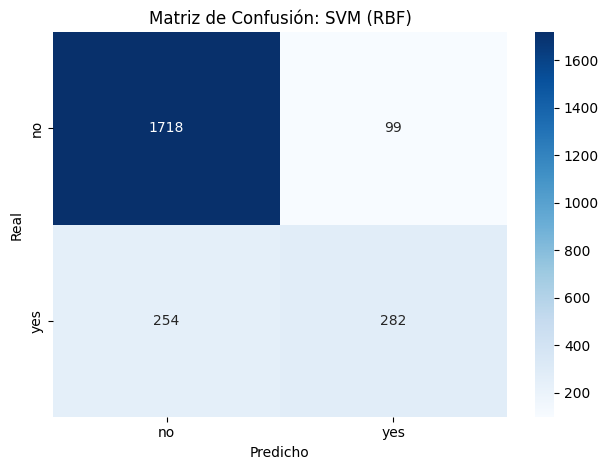


Comparación de Modelos (incluyendo SVM):
                     accuracy  precision    recall  f1-score       auc
Logistic Regression  0.845729   0.837157  0.845729  0.838400  0.902764
Decision Tree        0.839354   0.828768  0.839354  0.826936  0.871749
Random Forest        0.842329   0.838030  0.842329  0.821353  0.888445
XGBoost              0.847429   0.843232  0.847429  0.844905  0.903854
SVM (RBF)            0.849979   0.841347  0.849979  0.840368  0.900889


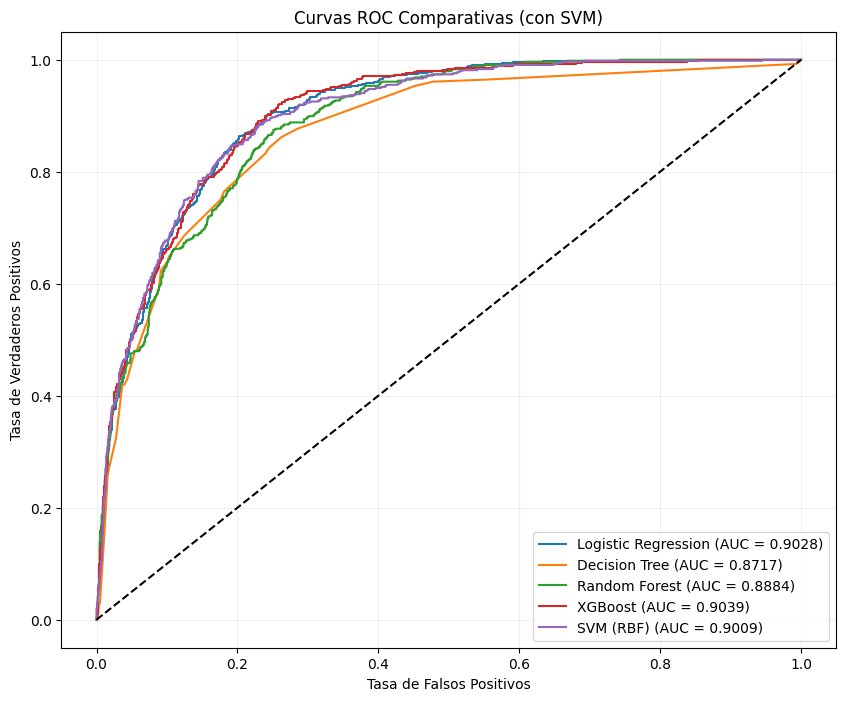

<Figure size 1200x600 with 0 Axes>

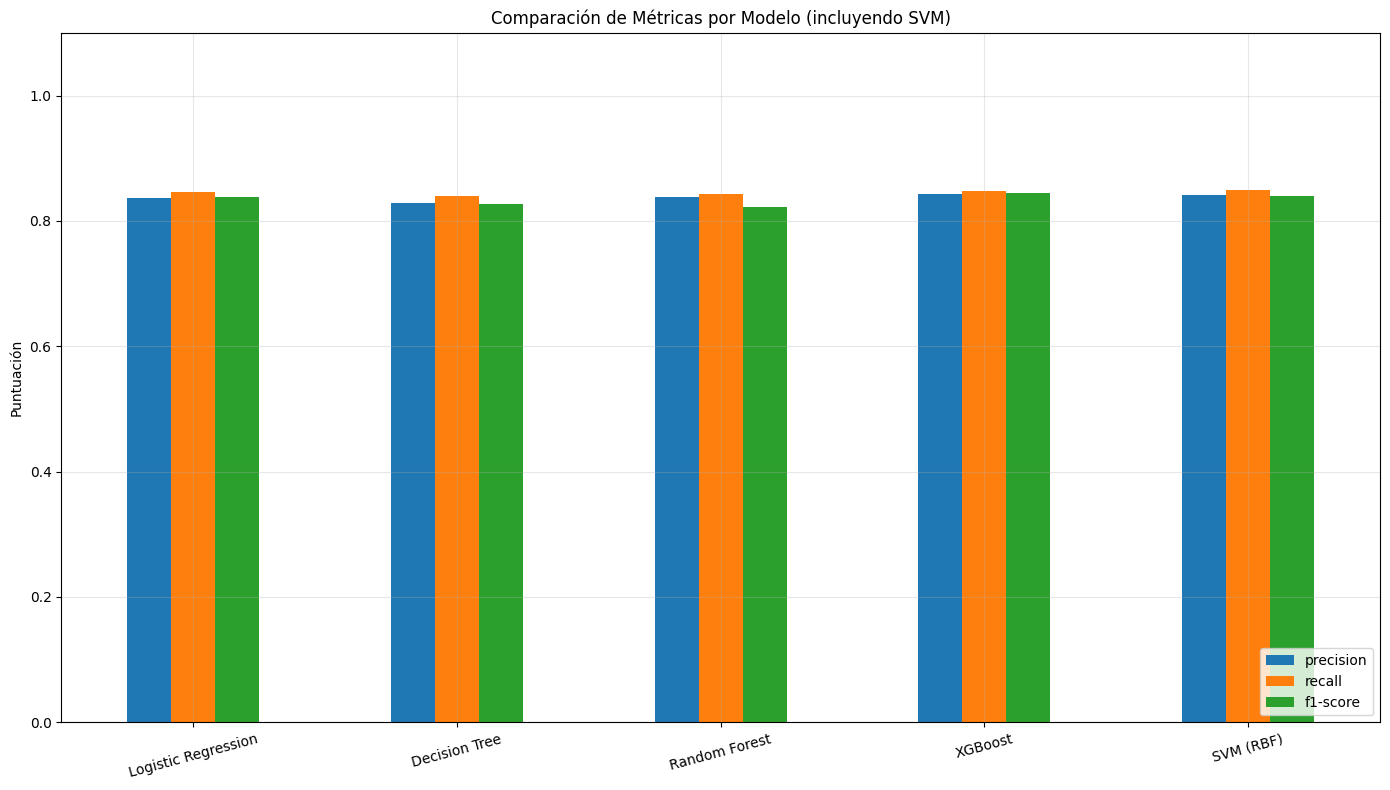

In [ ]:
# 1. Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


# 3. Variables seleccionadas
selected_features = [
    'duration', 'pdays', 'balance', 'campaign', 'age',
    'poutcome', 'housing', 'month', 'job'
]

X = df[selected_features]
y = df['y']

# 4. División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Columnas
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 6. Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 7. Modelos con SVM incluido
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42)
}

# 8. Evaluación
results = {}
roc_data = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1-score': report['weighted avg']['f1-score'],
        'auc': auc
    }

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

    plt.figure()
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['no', 'yes'], yticklabels=['no', 'yes'])
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

# 9. Resultados
results_df = pd.DataFrame(results).T
print("\nComparación de Modelos (incluyendo SVM):")
print(results_df)

# 10. Curvas ROC
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC Comparativas (con SVM)')
plt.legend(loc='lower right')
plt.grid(alpha=0.2)
plt.show()

# 11. Barras comparativas
plt.figure(figsize=(12, 6))
results_df[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(14, 8))
plt.title('Comparación de Métricas por Modelo (incluyendo SVM)')
plt.ylabel('Puntuación')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()